<a href="https://colab.research.google.com/github/Shubhi87/API/blob/master/Document_Retrieval.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Building a Production-Grade Document Q&A System
### Chunking · Embeddings · Semantic Search · Approximate Nearest Neighbours · End-to-end RAG

This notebook is a single, runnable tour of how real Retrieval-Augmented-Generation (RAG)
systems are built — the version you would actually ship, not a toy. We work on a **real,
large-document dataset** (full scientific papers), run **controlled chunking experiments**,
**benchmark every major FAISS index** (Flat, IVF, PQ, IVF+PQ, HNSW), and finally assemble a
**complete Document Q&A pipeline** with answer generation and evaluation.

It runs on a **free Google Colab tier** (CPU works; a T4 GPU just makes embedding faster).

---

#### The pipeline we are building

```
                          ┌──────────────────────────────────────────────────────────┐
   raw files              │                    INGESTION (offline)                    │
  PDF DOCX HTML  ───────► │  load → clean → CHUNK → EMBED → build VECTOR INDEX (FAISS) │
  scans (OCR)             └──────────────────────────────────────────────────────────┘
                                                  │ persisted index + metadata
                                                  ▼
   user question  ─────►  EMBED query ─► ANN SEARCH (top-k) ─► (rerank) ─► LLM with context ─►  grounded answer + citations
                          └────────────────────────  RETRIEVAL + GENERATION (online)  ──────────────────────┘
```

Every box above is its own section below. Each section is self-contained, explained first in
plain language, then implemented cleanly.

#### Roadmap

1. **Setup & configuration** — installs, device, one config object.
2. **Document processing** — PDF, DOCX, HTML and **OCR** basics with a unified loader.
3. **The dataset** — `allenai/qasper`: full papers + questions + gold evidence.
4. **Embeddings** — Sentence-Transformers (local, free) and **OpenAI** (drop-in), behind one interface.
5. **Chunking strategies** — fixed-size, token, recursive, **sliding window**, **semantic**.
6. **Chunking experiments** — measure retrieval quality vs. chunk size/strategy and pick a winner.
7. **Exact semantic search** — the correct baseline.
8. **Approximate search deep-dive** — IVF, PQ, IVF+PQ, HNSW, each explained and measured.
9. **ANN benchmark** — recall vs. latency vs. memory; when to use which.
10. **Production touches** — persistence, metadata filters, hybrid (BM25+dense), reranking.

> **How to read this notebook.** Run top-to-bottom once. Sections 5–9 reuse a small set of clean
> intermediate objects (`CORPUS`, `EVALSET`, an `Embedder`, and FAISS indexes), so the code stays
> short. Knobs live in the `CFG` object in Section 1 — change them there, not scattered around.

## 1 · Setup & configuration

Two install groups: Python packages (pip) and two system binaries for OCR
(`tesseract` for the OCR engine, `poppler` for rendering PDF pages to images).

> On Colab you can ignore pip's dependency-resolver warnings. If any `import` fails right after
> install, use **Runtime → Restart session** once and re-run — packages are already on disk.

In [ ]:
# --- System binaries for the OCR demo (safe to skip if you don't need OCR) ---
!apt-get -qq update  > /dev/null 2>&1
!apt-get -qq install -y tesseract-ocr poppler-utils > /dev/null 2>&1
print("tesseract + poppler installed (for the OCR section).")

tesseract + poppler installed (for the OCR section).


In [ ]:
# --- Python packages. Versions pinned to a coherent, current set. ---
%pip install -q \
  "langchain>=0.3,<0.4" "langchain-community>=0.3,<0.4" "langchain-text-splitters>=0.3,<0.4" \
  "langchain-huggingface>=0.1,<0.3" "langchain-openai>=0.2,<0.4" "langchain-experimental>=0.3,<0.4" \
  "sentence-transformers>=3.0" "transformers>=4.45" "accelerate>=0.30" "faiss-cpu>=1.8" "datasets>=2.19,<3.0" \
  "rank-bm25" "tiktoken" "pypdf" "docx2txt" "python-docx" "beautifulsoup4" "lxml" "fpdf2" \
  "pytesseract" "pdf2image" "Pillow" "matplotlib" "pandas"
print("done.")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.0/81.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 54.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 55.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.2/209.2 kB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 53.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 25.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 346.3/346.3 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.0/253.0 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 327.1/327.1 kB 19.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 9.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 461.3/461.3 kB 21.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [ ]:
# --- Imports, device detection, reproducibility ---
import os, re, time, json, math, random, warnings, textwrap
from dataclasses import dataclass, field
from typing import List, Dict, Tuple, Callable, Optional, Any
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
random.seed(42); np.random.seed(42)

try:
    import torch
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
except Exception:
    DEVICE = "cpu"

pd.set_option("display.max_colwidth", 90)
plt.rcParams["figure.figsize"] = (9, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

print(f"Device for embeddings: {DEVICE}")
print("If this says 'cpu' and you want speed: Runtime → Change runtime type → T4 GPU.")

Device for embeddings: cuda
If this says 'cpu' and you want speed: Runtime → Change runtime type → T4 GPU.


### One configuration object

Everything tunable lives here. Treat this as the notebook's control panel.

In [ ]:
@dataclass
class Config:
    # dataset
    dataset_name: str = "allenai/qasper"
    split: str = "validation"        # ~281 papers; small enough for the free tier
    max_papers: int = 8000             # ↑ for a bigger index (more chunks); ↓ if CPU-bound
    max_eval_questions: int = 15000    # questions used for retrieval evaluation

    # embeddings
    sbert_model: str = "sentence-transformers/all-MiniLM-L6-v2"   # 384-dim, fast, solid
    openai_model: str = "text-embedding-3-small"                  # used only if a key is set
    embed_batch_size: int = 64
    normalize: bool = True           # unit-norm vectors → inner product == cosine

    # default chunking (the experiments in §6 override these)
    chunk_size: int = 600            # characters
    chunk_overlap: int = 120

    # retrieval / search
    top_k: int = 5                   # chunks fed to the LLM
    eval_k: int = 10                 # k used when scoring retrieval

    # generation
    chat_model: str = "gpt-4o-mini"          # OpenAI model, used only if OPENAI_API_KEY is set
    local_llm: str = "Qwen/Qwen2.5-1.5B-Instruct"  # modern open generative LLM for the no-key path
    max_new_tokens: int = 256                # answer length cap for generation
    seed: int = 42

CFG = Config()
print(CFG)

Config(dataset_name='allenai/qasper', split='validation', max_papers=8000, max_eval_questions=15000, sbert_model='sentence-transformers/all-MiniLM-L6-v2', openai_model='text-embedding-3-small', embed_batch_size=64, normalize=True, chunk_size=600, chunk_overlap=120, top_k=5, eval_k=10, chat_model='gpt-4o-mini', local_llm='Qwen/Qwen2.5-1.5B-Instruct', max_new_tokens=256, seed=42)


### (Optional) OpenAI key

The notebook is **fully runnable without any API key** — Sentence-Transformers handles
embeddings locally and a small local model handles answering. If you *do* set a key, the
OpenAI embedding and the LLM-answering cells light up automatically. Nothing else changes.

In [ ]:
# Optional: paste a key to enable the OpenAI paths. Leave empty to stay 100% local & free.
# On Colab you can also use the secrets manager (key icon) instead of pasting here.
os.environ.setdefault("OPENAI_API_KEY", "")   # e.g. "sk-..."

try:
    from google.colab import userdata          # pull from Colab Secrets if present
    if not os.environ["OPENAI_API_KEY"]:
        os.environ["OPENAI_API_KEY"] = userdata.get("OPENAI_API_KEY") or ""
except Exception:
    pass

HAS_OPENAI = bool(os.environ.get("OPENAI_API_KEY"))
print("OpenAI paths:", "ENABLED" if HAS_OPENAI else "disabled (local-only mode — totally fine)")

OpenAI paths: disabled (local-only mode — totally fine)


## 2 · Document processing — PDF · DOCX · HTML · OCR

Before anything can be searched, raw files must become clean text. In production your corpus is
a messy pile of formats. We cover the four you meet most often and wrap them in **one dispatcher**,
`load_document(path)`, that returns LangChain `Document` objects (text + metadata) regardless of
the source format.

We first synthesize one small file of each type so the notebook is self-contained, then read them
back with the appropriate loader.

In [ ]:
# Make a scratch folder and synthesize one sample file per format.
import os
os.makedirs("/content/samples", exist_ok=True) if os.path.isdir("/content") else os.makedirs("samples", exist_ok=True)
SAMP = "/content/samples" if os.path.isdir("/content") else "samples"

SAMPLE_TEXT = (
    "Retrieval-Augmented Generation (RAG) grounds a language model in an external corpus. "
    "Instead of relying only on parametric memory, the system retrieves relevant passages at "
    "query time and conditions generation on them. This reduces hallucination and lets the "
    "knowledge base be updated without retraining the model."
)

# --- PDF (fpdf2) ---
from fpdf import FPDF
pdf = FPDF(); pdf.add_page(); pdf.set_font("Helvetica", size=12)
pdf.multi_cell(0, 8, "A Short Note on RAG\n\n" + SAMPLE_TEXT)
pdf.output(f"{SAMP}/sample.pdf")

# --- DOCX (python-docx) ---
from docx import Document as Docx
d = Docx(); d.add_heading("A Short Note on RAG", level=1); d.add_paragraph(SAMPLE_TEXT)
d.add_paragraph("Section: Why retrieval helps")
d.add_paragraph("Retrieval keeps answers current and attributable to sources.")
d.save(f"{SAMP}/sample.docx")

# --- HTML ---
html = f"""<!doctype html><html><head><title>RAG note</title></head>
<body><h1>A Short Note on RAG</h1><p>{SAMPLE_TEXT}</p>
<p>Embeddings turn text into vectors so that similar meaning lands nearby.</p></body></html>"""
open(f"{SAMP}/sample.html", "w").write(html)

print("Created:", os.listdir(SAMP))

Created: ['sample.docx', 'sample.html', 'sample.pdf']


### 2.1 · PDF, DOCX, HTML with LangChain loaders

LangChain ships a loader per format. Each returns `Document(page_content=..., metadata=...)`.
The point of using them (rather than hand-parsing) is uniform output and battle-tested edge-case
handling (encrypted PDFs, weird encodings, nested HTML).

In [ ]:
from langchain_community.document_loaders import PyPDFLoader, Docx2txtLoader, BSHTMLLoader

def short(t, n=160): return (t[:n] + " …") if len(t) > n else t

pdf_docs  = PyPDFLoader(f"{SAMP}/sample.pdf").load()
docx_docs = Docx2txtLoader(f"{SAMP}/sample.docx").load()
html_docs = BSHTMLLoader(f"{SAMP}/sample.html").load()

for label, docs in [("PDF", pdf_docs), ("DOCX", docx_docs), ("HTML", html_docs)]:
    print(f"\n=== {label} === ({len(docs)} document object[s])")
    print("metadata:", docs[0].metadata)
    print("text    :", short(docs[0].page_content.replace(chr(10), " ").strip()))


=== PDF === (1 document object[s])
metadata: {'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '2026-06-09T12:16:22+00:00', 'source': '/content/samples/sample.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1'}
text    : A Short Note on RAG Retrieval-Augmented Generation (RAG) grounds a language model in an external corpus. Instead of relying only on parametric memory, the syste …

=== DOCX === (1 document object[s])
metadata: {'source': '/content/samples/sample.docx'}
text    : A Short Note on RAG  Retrieval-Augmented Generation (RAG) grounds a language model in an external corpus. Instead of relying only on parametric memory, the syst …

=== HTML === (1 document object[s])
metadata: {'source': '/content/samples/sample.html', 'title': 'RAG note'}
text    : RAG note A Short Note on RAGRetrieval-Augmented Generation (RAG) grounds a language model in an external corpus. Instead of relying only on parametric memory, t …


### 2.2 · OCR basics — reading text from images / scanned PDFs

Many "PDFs" are just photos of pages: there is no text layer, so the loaders above return nothing.
The fix is **Optical Character Recognition**. The standard open-source stack is **Tesseract**
(the OCR engine) driven by **pytesseract**, with **pdf2image/poppler** to rasterize PDF pages into
images first.

The minimal pipeline is: `PDF page → image → tesseract → text`. We demonstrate the core step on a
synthesized image, then show the scanned-PDF wrapper.

In [ ]:
# Synthesize an "image of text" (stands in for a scanned page), then OCR it.
from PIL import Image, ImageDraw, ImageFont
import pytesseract

img = Image.new("RGB", (760, 200), "white")
draw = ImageDraw.Draw(img)
try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf", 22)
except Exception:
    font = ImageFont.load_default()
draw.multiline_text((20, 30),
    "Optical Character Recognition turns\npixels of text back into characters.\nTesseract is the workhorse engine.",
    fill="black", font=font, spacing=10)
img.save(f"{SAMP}/scanned.png")

ocr_text = pytesseract.image_to_string(Image.open(f"{SAMP}/scanned.png"))
print("OCR output:\n", ocr_text.strip())

OCR output:
 Optical Character Recognition turns
phelsoltextback intocharacters
Tesseract isthe workhorse engine.


In [ ]:
def ocr_pdf(path: str) -> str:
    """OCR a scanned (image-only) PDF: rasterize each page, then run Tesseract.
    Used as a fallback only when a normal PDF loader yields little/no text."""
    from pdf2image import convert_from_path
    pages = convert_from_path(path, dpi=200)
    return "\n\n".join(pytesseract.image_to_string(p) for p in pages)

# (Our sample.pdf has a real text layer, so PyPDFLoader already handles it.
#  ocr_pdf() is what you'd call when len(extracted_text) is suspiciously small.)
print("ocr_pdf() ready — call it when a PDF has no extractable text layer.")

ocr_pdf() ready — call it when a PDF has no extractable text layer.


### 2.3 · A single unified loader

In a real ingestion job you do not want a `for`-loop of `if extension == ...`. Wrap the dispatch
once. This function is the only thing the rest of an ingestion pipeline needs to know about file
formats — and it transparently falls back to OCR when a PDF has no text layer.

In [ ]:
from pathlib import Path
from langchain_core.documents import Document

def load_document(path: str) -> List[Document]:
    """Format-agnostic loader → list[Document]. Adds source/format metadata.
    Falls back to OCR for image-only PDFs."""
    ext = Path(path).suffix.lower()
    if ext == ".pdf":
        docs = PyPDFLoader(path).load()
        if sum(len(d.page_content.strip()) for d in docs) < 32:   # likely a scanned PDF
            docs = [Document(page_content=ocr_pdf(path), metadata={"ocr": True})]
    elif ext == ".docx":
        docs = Docx2txtLoader(path).load()
    elif ext in (".html", ".htm"):
        docs = BSHTMLLoader(path).load()
    elif ext in (".png", ".jpg", ".jpeg", ".tiff"):
        docs = [Document(page_content=pytesseract.image_to_string(Image.open(path)), metadata={"ocr": True})]
    elif ext in (".txt", ".md"):
        docs = [Document(page_content=Path(path).read_text(errors="ignore"))]
    else:
        raise ValueError(f"Unsupported format: {ext}")
    for d in docs:
        d.metadata.update({"source": os.path.basename(path), "format": ext.lstrip(".")})
    return docs

for f in ["sample.pdf", "sample.docx", "sample.html", "scanned.png"]:
    docs = load_document(f"{SAMP}/{f}")
    print(f"{f:14s} → {len(docs)} doc[s], {sum(len(d.page_content) for d in docs):5d} chars, meta={docs[0].metadata}")

sample.pdf     → 1 doc[s],   334 chars, meta={'producer': 'PyPDF', 'creator': 'PyPDF', 'creationdate': '2026-06-09T12:16:22+00:00', 'source': 'sample.pdf', 'total_pages': 1, 'page': 0, 'page_label': '1', 'format': 'pdf'}
sample.docx    → 1 doc[s],   427 chars, meta={'source': 'sample.docx', 'format': 'docx'}
sample.html    → 1 doc[s],   414 chars, meta={'source': 'sample.html', 'title': 'RAG note', 'format': 'html'}
scanned.png    → 1 doc[s],   102 chars, meta={'ocr': True, 'source': 'scanned.png', 'format': 'png'}


## 3 · The dataset — `allenai/qasper` (real, large documents)

For the experiments we need genuinely **long documents** with **real questions** and, ideally,
**gold evidence** so we can *measure* whether retrieval finds the right passage. **QASPER**
(Question Answering over Scientific Papers) fits perfectly:

- documents are **full NLP research papers** — multi-section, multi-page (exactly where chunking matters);
- questions were written by NLP practitioners who had only seen the title + abstract;
- every answer is annotated with the **evidence paragraphs** that support it.

That evidence is the key: it turns "did retrieval work?" from a vibe into a number.

We isolate all dataset-specific parsing in this one section. Everything downstream consumes two
clean objects:

- **`CORPUS`** — `list[Document]`, one per paper (`page_content` + metadata).
- **`EVALSET`** — `list[dict]`, each `{question, paper_id, evidence:[...], answer}` for answerable questions.

In [ ]:
from datasets import load_dataset

try:
    raw = load_dataset(CFG.dataset_name, split=CFG.split)
    print(f"Loaded {CFG.dataset_name} [{CFG.split}]: {len(raw)} papers")
except Exception as e:
    raise RuntimeError(
        "Could not download QASPER. Check the Colab internet connection and that "
        "`datasets` is installed. Original error:\n" + repr(e)
    )

# Peek at the schema once so the parsing below is easy to adapt if the dataset ever changes.
ex = raw[0]
print("\nTop-level fields:", list(ex.keys()))
print("full_text keys :", list(ex["full_text"].keys()))
print("qas keys       :", list(ex["qas"].keys()))

Generating train split:   0%|          | 0/888 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/281 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/416 [00:00<?, ? examples/s]

Loaded allenai/qasper [validation]: 281 papers

Top-level fields: ['id', 'title', 'abstract', 'full_text', 'qas', 'figures_and_tables']
full_text keys : ['section_name', 'paragraphs']
qas keys       : ['question', 'question_id', 'nlp_background', 'topic_background', 'paper_read', 'search_query', 'question_writer', 'answers']


In [ ]:
def paper_to_text(ex: dict) -> str:
    """Flatten one QASPER paper into a single clean document string."""
    parts = []
    if ex.get("title"):    parts.append(ex["title"].strip())
    if ex.get("abstract"): parts.append("Abstract\n" + ex["abstract"].strip())
    ft = ex.get("full_text", {}) or {}
    names = ft.get("section_name", []) or []
    paras = ft.get("paragraphs", []) or []
    for name, plist in zip(names, paras):
        if name and name.strip():
            parts.append(name.strip())
        for p in (plist or []):
            if p and p.strip():
                parts.append(p.strip())
    return "\n\n".join(parts)

def paper_qas(ex: dict) -> List[dict]:
    """Extract answerable (question, evidence, answer) triples for one paper."""
    out = []
    qas = ex.get("qas", {}) or {}
    questions = qas.get("question", []) or []
    answer_groups = qas.get("answers", []) or []
    for q, grp in zip(questions, answer_groups):
        ans_items = grp.get("answer", []) if isinstance(grp, dict) else []
        evidence, free_form, answerable = [], None, False
        for a in ans_items:
            if not isinstance(a, dict):
                continue
            for ev in (a.get("evidence", []) or []):
                if ev and ev.strip() and not ev.strip().startswith("FLOAT SELECTED"):
                    evidence.append(ev.strip()); answerable = True
            if a.get("free_form_answer"):
                free_form = a["free_form_answer"]; answerable = True
            if a.get("extractive_spans"):
                answerable = True
            if a.get("yes_no") is not None:
                answerable = True
        # de-dup evidence, keep order
        seen, ev_unique = set(), []
        for e in evidence:
            if e not in seen:
                seen.add(e); ev_unique.append(e)
        out.append({"question": q, "evidence": ev_unique,
                    "answer": free_form, "answerable": answerable})
    return out

In [ ]:
# Build CORPUS (one Document per paper) and EVALSET (answerable questions with evidence).
from langchain_core.documents import Document

CORPUS: List[Document] = []
EVALSET: List[dict] = []

for i in range(min(CFG.max_papers, len(raw))):
    ex = raw[i]
    pid = ex.get("id", f"paper_{i}")
    text = paper_to_text(ex)
    if len(text) < 500:           # skip near-empty parses
        continue
    CORPUS.append(Document(page_content=text,
                           metadata={"paper_id": pid, "title": ex.get("title", ""), "source": pid}))
    for qa in paper_qas(ex):
        if qa["answerable"] and qa["evidence"]:
            EVALSET.append({"paper_id": pid, **qa})

# Cap the eval set (keep it snappy on the free tier) — shuffle for a representative sample.
random.Random(CFG.seed).shuffle(EVALSET)
EVALSET = EVALSET[:CFG.max_eval_questions]

print(f"CORPUS : {len(CORPUS)} papers")
print(f"EVALSET: {len(EVALSET)} answerable questions (with gold evidence)")
print("\nExample question:", EVALSET[0]["question"])
print("Its evidence[0]:", short(EVALSET[0]["evidence"][0], 200))

CORPUS : 281 papers
EVALSET: 892 answerable questions (with gold evidence)

Example question: Is the LSTM baseline a sub-word model?
Its evidence[0]: The original BERT has two training objectives: 'Masked language modelling', in which you mask input tokens randomly and then predict the masked tokens using the left and right context. Additionally, t …


### 3.1 · A quick look at the data

How long are these documents, really? This justifies the whole chunking discussion: each paper is
*far* larger than an embedding model's context window, so it must be split.

Words per paper:
count      281.0
mean      3648.0
std       1889.0
min        660.0
25%       2408.0
50%       3484.0
75%       4346.0
max      14894.0

A MiniLM/OpenAI embedding handles a few hundred words at a time, but the median paper is ~3484 words → it MUST be chunked.


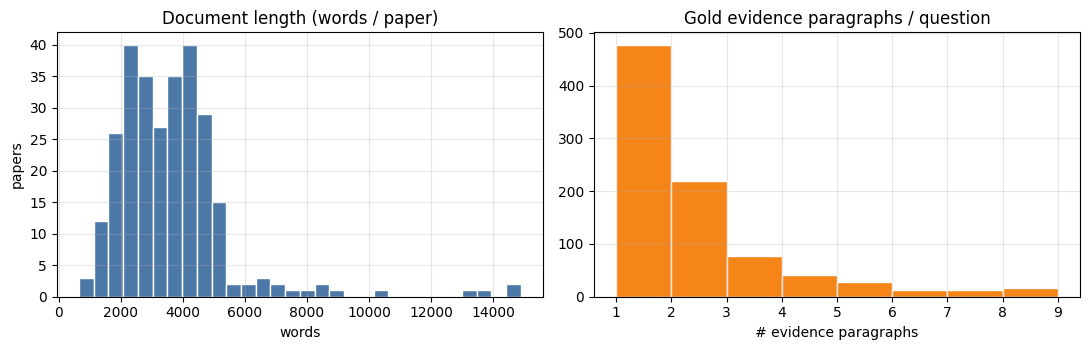

In [ ]:
def n_words(t: str) -> int: return len(t.split())

word_counts = np.array([n_words(d.page_content) for d in CORPUS])
n_questions_per_paper = pd.Series([e["paper_id"] for e in EVALSET]).value_counts()

print("Words per paper:")
print(pd.Series(word_counts).describe().round(0).to_string())
print(f"\nA MiniLM/OpenAI embedding handles a few hundred words at a time, but the median paper is "
      f"~{int(np.median(word_counts))} words → it MUST be chunked.")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].hist(word_counts, bins=30, color="#4C78A8", edgecolor="white")
ax[0].set_title("Document length (words / paper)"); ax[0].set_xlabel("words"); ax[0].set_ylabel("papers")
ax[1].hist([len(e["evidence"]) for e in EVALSET], bins=range(1, 10), color="#F58518", edgecolor="white")
ax[1].set_title("Gold evidence paragraphs / question"); ax[1].set_xlabel("# evidence paragraphs")
plt.tight_layout(); plt.show()

## 4 · Embeddings

An embedding maps text to a vector so that **semantic similarity becomes geometric proximity**:
"How do I cite a source?" and "What is the citation format?" land close together even though they
share few words. Two production-standard choices:

| | Sentence-Transformers (SBERT) | OpenAI |
|---|---|---|
| where it runs | **locally**, free, offline | hosted API (paid) |
| default model | `all-MiniLM-L6-v2` (384-d) | `text-embedding-3-small` (1536-d) |
| good for | most workloads, full control, privacy | top quality with zero infra |

We hide both behind a single `Embedder` interface so nothing downstream cares which one you picked.
A crucial detail: we **L2-normalize** every vector. With unit-length vectors, **inner product equals
cosine similarity**, which lets us use one FAISS metric (inner product) for *every* index type later.

In [ ]:
from sentence_transformers import SentenceTransformer

class Embedder:
    """Common interface: .embed(texts) -> float32 array (n, dim), L2-normalized if CFG.normalize."""
    name: str; dim: int
    def embed(self, texts: List[str], show_progress: bool = False) -> np.ndarray: ...
    def embed_query(self, text: str) -> np.ndarray:
        return self.embed([text])[0]

class SbertEmbedder(Embedder):
    def __init__(self, model_name: str = CFG.sbert_model):
        self.model = SentenceTransformer(model_name, device=DEVICE)
        self.name = model_name.split("/")[-1]
        self.dim = self.model.get_sentence_embedding_dimension()
    def embed(self, texts, show_progress=False):
        v = self.model.encode(texts, batch_size=CFG.embed_batch_size,
                              normalize_embeddings=CFG.normalize,
                              convert_to_numpy=True, show_progress_bar=show_progress)
        return v.astype("float32")

EMB = SbertEmbedder()       # the default embedder used throughout
print(f"Embedder: {EMB.name}  |  dim={EMB.dim}  |  device={DEVICE}")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedder: all-MiniLM-L6-v2  |  dim=384  |  device=cuda


In [ ]:
class OpenAIEmbedder(Embedder):
    """Drop-in OpenAI embeddings. Only usable when OPENAI_API_KEY is set."""
    def __init__(self, model_name: str = CFG.openai_model):
        from openai import OpenAI
        self.client = OpenAI()
        self.name = model_name; self.model_name = model_name
        self.dim = 1536 if "small" in model_name else 3072
    def embed(self, texts, show_progress=False):
        out = []
        for i in range(0, len(texts), 256):                 # API batch limit
            resp = self.client.embeddings.create(model=self.model_name, input=texts[i:i+256])
            out.extend([e.embedding for e in resp.data])
        v = np.asarray(out, dtype="float32")
        if CFG.normalize:                                   # match SBERT: unit norm → IP == cosine
            v /= (np.linalg.norm(v, axis=1, keepdims=True) + 1e-12)
        return v

OPENAI_EMB = OpenAIEmbedder() if HAS_OPENAI else None
print("OpenAI embedder:", "ready" if OPENAI_EMB else "skipped (no key) — using SBERT everywhere")

OpenAI embedder: skipped (no key) — using SBERT everywhere


### 4.1 · Sanity check — does the geometry mean anything?

Embed a few sentences and look at pairwise cosine similarity. We expect the two paraphrases of the
same idea to score highest, and the unrelated sentence to score lowest with everything.

In [ ]:
probe = [
    "How do I cite a source in this format?",     # 0
    "What is the required citation style?",        # 1  (paraphrase of 0)
    "The cat slept on the warm windowsill.",       # 2  (unrelated)
    "Approximate nearest-neighbour search trades a little accuracy for speed.",  # 3
]
V = EMB.embed(probe)                 # already normalized → V @ V.T is cosine similarity
sim = V @ V.T
df = pd.DataFrame(sim, columns=[f"s{i}" for i in range(len(probe))],
                       index=[f"s{i}: {short(p,38)}" for i, p in enumerate(probe)])
print(df.round(2).to_string())
print("\ns0–s1 (paraphrases) should be the highest off-diagonal pair; s2 (the cat) lowest with the rest.")

                                                s0    s1    s2    s3
s0: How do I cite a source in this format?    1.00  0.69  0.07 -0.07
s1: What is the required citation style?      0.69  1.00 -0.02  0.02
s2: The cat slept on the warm windowsill.     0.07 -0.02  1.00 -0.04
s3: Approximate nearest-neighbour search t … -0.07  0.02 -0.04  1.00

s0–s1 (paraphrases) should be the highest off-diagonal pair; s2 (the cat) lowest with the rest.


## 5 · Chunking strategies

A chunk is the atomic unit that gets embedded and retrieved. Chunking is the single most
under-rated lever in RAG quality:

- **too small** → each chunk lacks context; the answer is split across several chunks and none is
  individually convincing;
- **too large** → one vector must summarize many ideas, so the embedding is "blurry" and irrelevant
  text dilutes the match; you also waste the LLM's context window.

We implement the five strategies you actually choose between in production, each as a simple
`text -> list[str]` function so they are interchangeable.

| strategy | splits on | keeps meaning together? | cost |
|---|---|---|---|
| **fixed-size** | character count | no (cuts mid-sentence) | trivial |
| **token-based** | token count | no, but respects model budget | trivial |
| **recursive** | paragraphs→sentences→words | mostly (prefers natural boundaries) | trivial |
| **sliding window** | sentences, with overlap | yes, with redundancy for recall | cheap |
| **semantic** | embedding-similarity dips | yes (topic shifts) | needs embeddings |

In [ ]:
from langchain_text_splitters import (CharacterTextSplitter, RecursiveCharacterTextSplitter,
                                       TokenTextSplitter)

# ---- 1) fixed-size (hard character windows; CharacterTextSplitter with an empty separator) ----
def fixed_splitter(size: int, overlap: int) -> Callable[[str], List[str]]:
    sp = CharacterTextSplitter(separator="", chunk_size=size, chunk_overlap=overlap)
    return lambda t: sp.split_text(t)

# ---- 2) token-based (counts tiktoken tokens; respects the model's real budget) ----
def token_splitter(tokens: int, overlap: int) -> Callable[[str], List[str]]:
    sp = TokenTextSplitter(chunk_size=tokens, chunk_overlap=overlap)
    return lambda t: sp.split_text(t)

# ---- 3) recursive (the sensible default: try paragraph, then line, then sentence, then word) ----
def recursive_splitter(size: int, overlap: int) -> Callable[[str], List[str]]:
    sp = RecursiveCharacterTextSplitter(
        chunk_size=size, chunk_overlap=overlap,
        separators=["\n\n", "\n", ". ", " ", ""])
    return lambda t: sp.split_text(t)

# ---- 4) sliding window over SENTENCES (overlapping windows → redundancy helps recall) ----
def sliding_splitter(window_sents: int = 5, stride_sents: int = 3) -> Callable[[str], List[str]]:
    def split(t: str) -> List[str]:
        sents = [s.strip() for s in re.split(r"(?<=[.!?])\s+", t) if s.strip()]
        if not sents: return []
        out, i = [], 0
        while i < len(sents):
            out.append(" ".join(sents[i:i + window_sents]))
            if i + window_sents >= len(sents): break
            i += stride_sents
        return out
    return split

print("Fixed / token / recursive / sliding splitters ready.")

Fixed / token / recursive / sliding splitters ready.


In [ ]:
# ---- 5) semantic chunking: split where consecutive-sentence embedding similarity drops ----
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_experimental.text_splitter import SemanticChunker

lc_embeddings = HuggingFaceEmbeddings(
    model_name=CFG.sbert_model,
    model_kwargs={"device": DEVICE},
    encode_kwargs={"normalize_embeddings": True})

def semantic_splitter(threshold_type: str = "percentile", amount: int = 90) -> Callable[[str], List[str]]:
    chunker = SemanticChunker(lc_embeddings,
                              breakpoint_threshold_type=threshold_type,
                              breakpoint_threshold_amount=amount)
    return lambda t: chunker.split_text(t)

print("Semantic splitter ready (embeds sentences, so it is the slowest of the five).")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Semantic splitter ready (embeds sentences, so it is the slowest of the five).


### 5.1 · See each strategy on one real paragraph

Same input, five strategies. Notice how fixed-size slices mid-word, recursive prefers sentence
ends, sliding-window chunks overlap on purpose, and semantic chunks vary in length because they
follow topic shifts rather than a fixed budget.

In [ ]:
sample_text = CORPUS[0].page_content[:1400]
print("INPUT (first 1400 chars of paper 0):\n" + textwrap.fill(sample_text[:400], 100) + " …\n")

demos = {
    "fixed (300/60)":      fixed_splitter(300, 60),
    "token (80/20)":       token_splitter(80, 20),
    "recursive (300/60)":  recursive_splitter(300, 60),
    "sliding (5 sent/3)":  sliding_splitter(5, 3),
    "semantic (pct 90)":   semantic_splitter("percentile", 90),
}
for name, fn in demos.items():
    chunks = fn(sample_text)
    avg = int(np.mean([len(c) for c in chunks])) if chunks else 0
    print(f"\n● {name:18s} → {len(chunks):2d} chunks, avg {avg} chars")
    print("   first chunk:", short(chunks[0].replace(chr(10), ' '), 130) if chunks else "—")

INPUT (first 1400 chars of paper 0):
Cross-lingual Pre-training Based Transfer for Zero-shot Neural Machine Translation  Abstract
Transfer learning between different language pairs has shown its effectiveness for Neural Machine
Translation (NMT) in low-resource scenario. However, existing transfer methods involving a common
target language are far from success in the extreme scenario of zero-shot translation, due to the
language spac …


● fixed (300/60)     →  6 chunks, avg 283 chars
   first chunk: Cross-lingual Pre-training Based Transfer for Zero-shot Neural Machine Translation  Abstract Transfer learning between different l …

● token (80/20)      →  5 chunks, avg 364 chars
   first chunk: Cross-lingual Pre-training Based Transfer for Zero-shot Neural Machine Translation  Abstract Transfer learning between different l …

● recursive (300/60) →  9 chunks, avg 155 chars
   first chunk: Cross-lingual Pre-training Based Transfer for Zero-shot Neural Machine Translation

● sliding (5 s

### 5.2 · Turn a strategy into a corpus of chunk `Document`s

Downstream we always need `Document`s carrying enough metadata to (a) trace a chunk back to its
paper and (b) score retrieval. This helper applies any `text -> list[str]` splitter to the whole
corpus and stamps that metadata on every chunk.

In [ ]:
def chunk_corpus(splitter: Callable[[str], List[str]], strategy: str,
                 docs: List[Document] = None) -> List[Document]:
    docs = docs if docs is not None else CORPUS
    chunks: List[Document] = []
    for d in docs:
        for j, piece in enumerate(splitter(d.page_content)):
            piece = piece.strip()
            if len(piece) < 20:               # drop slivers
                continue
            chunks.append(Document(
                page_content=piece,
                metadata={"paper_id": d.metadata["paper_id"], "title": d.metadata["title"],
                          "strategy": strategy, "chunk_id": f'{d.metadata["paper_id"]}::{j}'}))
    return chunks

_demo_chunks = chunk_corpus(recursive_splitter(CFG.chunk_size, CFG.chunk_overlap), "recursive")
print(f"Recursive chunking of {len(CORPUS)} papers → {len(_demo_chunks)} chunks")
print("example chunk metadata:", _demo_chunks[0].metadata)

Recursive chunking of 281 papers → 17013 chunks
example chunk metadata: {'paper_id': '1912.01214', 'title': 'Cross-lingual Pre-training Based Transfer for Zero-shot Neural Machine Translation', 'strategy': 'recursive', 'chunk_id': '1912.01214::0'}


## 6 · Chunking experiments — measure, don't guess

We now turn the table above into numbers. For each strategy we: chunk the corpus → embed every
chunk → build an **exact** index → run all evaluation questions → and check whether a **gold
evidence** passage shows up in the top-k.

A retrieved chunk counts as **relevant** to a question when it comes from the right paper *and*
shares a substantial fraction of its words with one of that question's gold evidence paragraphs
(overlap coefficient ≥ 0.5). This tolerates the fact that chunk boundaries rarely line up exactly
with evidence boundaries. Two metrics:

- **Hit@k** — fraction of questions with at least one relevant chunk in the top-k (can the system
  *find* the answer at all?).
- **MRR** — mean reciprocal rank of the first relevant chunk (does it find it *near the top*?).

In [ ]:
import faiss

_word_re = re.compile(r"[^a-z0-9 ]+")
def toks(t: str) -> set:
    return set(_word_re.sub(" ", t.lower()).split())

def overlap_coef(a: set, b: set) -> float:
    if not a or not b: return 0.0
    return len(a & b) / min(len(a), len(b))

def is_relevant(chunk: Document, q: dict, thr: float = 0.5) -> bool:
    """Relevant = same paper AND high word-overlap with any gold evidence paragraph."""
    if chunk.metadata.get("paper_id") != q["paper_id"]:
        return False
    ct = toks(chunk.page_content)
    return any(overlap_coef(toks(ev), ct) >= thr for ev in q["evidence"])

def score_retrieval(retrieved_per_q: List[List[Document]], queries: List[dict], k: int) -> dict:
    hits, rrs = [], []
    for retrieved, q in zip(retrieved_per_q, queries):
        flags = [is_relevant(c, q) for c in retrieved[:k]]
        hits.append(1.0 if any(flags) else 0.0)
        rr = next((1.0 / r for r, f in enumerate(flags, 1) if f), 0.0)
        rrs.append(rr)
    return {"hit@k": float(np.mean(hits)), "mrr": float(np.mean(rrs))}

In [ ]:
def embed_and_index(chunks: List[Document], embedder: Embedder):
    """Embed chunk texts and build an exact (Flat inner-product) index."""
    t0 = time.perf_counter()
    vecs = embedder.embed([c.page_content for c in chunks], show_progress=False)
    embed_s = time.perf_counter() - t0
    index = faiss.IndexFlatIP(embedder.dim)
    index.add(vecs)
    return index, vecs, embed_s

def retrieve(index, embedder, queries: List[dict], chunks: List[Document], k: int):
    qv = embedder.embed([q["question"] for q in queries])
    _, I = index.search(qv, k)
    return [[chunks[i] for i in row] for row in I]

In [ ]:
# The configurations to compare. (Semantic chunking embeds sentences, so it is the slow one —
# on CPU this whole cell can take a few minutes; on a T4 it is quick.)
chunking_configs = {
    "fixed-400/80":     fixed_splitter(400, 80),
    "fixed-800/160":    fixed_splitter(800, 160),
    "recursive-400/80": recursive_splitter(400, 80),
    "recursive-800/160":recursive_splitter(800, 160),
    "token-128/24":     token_splitter(128, 24),
    "sliding-5/3":      sliding_splitter(5, 3),
    "semantic-pct90":   semantic_splitter("percentile", 90),
}

results, store = [], {}
for name, splitter in chunking_configs.items():
    chunks = chunk_corpus(splitter, name)
    index, vecs, embed_s = embed_and_index(chunks, EMB)
    retrieved = retrieve(index, EMB, EVALSET, chunks, CFG.eval_k)
    sc = score_retrieval(retrieved, EVALSET, CFG.eval_k)
    avg_len = float(np.mean([len(c.page_content) for c in chunks]))
    results.append({"strategy": name, "chunks": len(chunks), "avg_chars": round(avg_len),
                    f"hit@{CFG.eval_k}": round(sc["hit@k"], 3), "MRR": round(sc["mrr"], 3),
                    "embed_s": round(embed_s, 1)})
    store[name] = {"chunks": chunks, "vecs": vecs}
    print(f"✓ {name:18s} {len(chunks):5d} chunks  hit@{CFG.eval_k}={sc['hit@k']:.3f}  MRR={sc['mrr']:.3f}")

res_df = pd.DataFrame(results).sort_values(f"hit@{CFG.eval_k}", ascending=False).reset_index(drop=True)
res_df

✓ fixed-400/80       21170 chunks  hit@10=0.254  MRR=0.138
✓ fixed-800/160      10618 chunks  hit@10=0.257  MRR=0.137
✓ recursive-400/80   25423 chunks  hit@10=0.316  MRR=0.175
✓ recursive-800/160  12610 chunks  hit@10=0.280  MRR=0.153
✓ token-128/24       14341 chunks  hit@10=0.267  MRR=0.141
✓ sliding-5/3        15529 chunks  hit@10=0.258  MRR=0.142
✓ semantic-pct90      4977 chunks  hit@10=0.271  MRR=0.138


,strategy,chunks,avg_chars,hit@10,MRR,embed_s
0,recursive-400/80,25423,269,0.316,0.175,34.3
1,recursive-800/160,12610,557,0.280,0.153,33.3
2,semantic-pct90,4977,1353,0.271,0.138,14.7
3,token-128/24,14341,577,0.267,0.141,25.0
4,sliding-5/3,15529,714,0.258,0.142,42.8
5,fixed-800/160,10618,791,0.257,0.137,31.6
6,fixed-400/80,21170,398,0.254,0.138,31.2


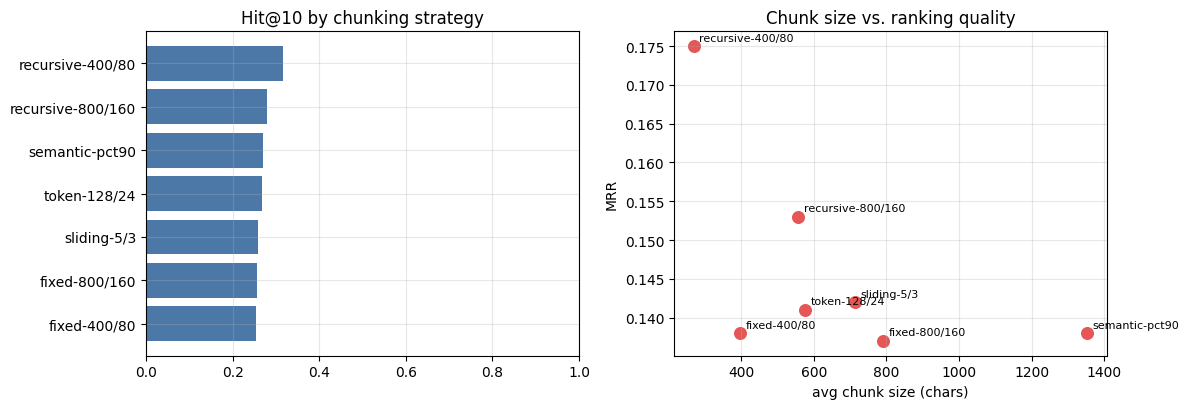

In [ ]:
# Visualize the trade-offs.
fig, ax = plt.subplots(1, 2, figsize=(12, 4.2))
order = res_df["strategy"]
ax[0].barh(order, res_df[f"hit@{CFG.eval_k}"], color="#4C78A8")
ax[0].set_title(f"Hit@{CFG.eval_k} by chunking strategy"); ax[0].invert_yaxis(); ax[0].set_xlim(0, 1)
ax[1].scatter(res_df["avg_chars"], res_df["MRR"], s=70, color="#E45756")
for _, r in res_df.iterrows():
    ax[1].annotate(r["strategy"], (r["avg_chars"], r["MRR"]), fontsize=8,
                   xytext=(4, 4), textcoords="offset points")
ax[1].set_xlabel("avg chunk size (chars)"); ax[1].set_ylabel("MRR"); ax[1].set_title("Chunk size vs. ranking quality")
plt.tight_layout(); plt.show()

### 6.1 · Pick a winner and freeze it

We select the configuration with the best Hit@k (ties broken by MRR) and reuse its chunks and
vectors for the rest of the notebook — no re-embedding. In practice the recursive splitter at a
moderate size, or sliding-window when recall matters most, tends to win; semantic chunking is
strongest when documents have sharp topic shifts but costs the most to build.

In [ ]:
best_name = res_df.iloc[0]["strategy"]
CHUNKS    = store[best_name]["chunks"]
CHUNK_VECS = store[best_name]["vecs"]
CHUNK_TEXTS = [c.page_content for c in CHUNKS]

print(f"WINNER: {best_name}")
print(f"Frozen corpus: {len(CHUNKS):,} chunks, vectors shape {CHUNK_VECS.shape}")
print("This (CHUNKS, CHUNK_VECS) is the canonical index input for §7–§11.")

# free the other configs' vectors to save RAM
for k in list(store):
    if k != best_name:
        store[k]["vecs"] = None

WINNER: recursive-400/80
Frozen corpus: 25,423 chunks, vectors shape (25423, 384)
This (CHUNKS, CHUNK_VECS) is the canonical index input for §7–§11.


## 7 · Semantic search — the exact baseline

Before approximating anything, build the **exact** search that every approximate method will be
measured against. With our unit-normalized vectors, `IndexFlatIP` computes the inner product =
**cosine similarity** between the query and every chunk, then returns the true top-k. It is
**100% accurate by definition** — and perfectly fast at our scale. Its only problem is that it
scans *every* vector, so cost grows linearly with corpus size; that is what §8 fixes.

We wrap it in a small `SemanticSearcher` so the query path (embed → search → attach metadata) is
one call. The same class will happily wrap an approximate index later — the interface never changes.

In [ ]:
class SemanticSearcher:
    """Embed a query, search a FAISS index, return (chunk, score) pairs with metadata."""
    def __init__(self, embedder: Embedder, chunks: List[Document], index: "faiss.Index"):
        self.embedder, self.chunks, self.index = embedder, chunks, index
    @classmethod
    def exact(cls, embedder, chunks, vecs):
        index = faiss.IndexFlatIP(embedder.dim); index.add(vecs)
        return cls(embedder, chunks, index)
    def search(self, query: str, k: int = CFG.top_k) -> List[Tuple[Document, float]]:
        qv = self.embedder.embed_query(query).reshape(1, -1)
        scores, ids = self.index.search(qv, k)
        return [(self.chunks[i], float(s)) for s, i in zip(scores[0], ids[0]) if i != -1]

searcher = SemanticSearcher.exact(EMB, CHUNKS, CHUNK_VECS)
print("Exact searcher ready over", len(CHUNKS), "chunks.")

Exact searcher ready over 25423 chunks.


In [ ]:
def show_results(query: str, hits: List[Tuple[Document, float]]):
    print("Q:", query, "\n" + "-" * 96)
    for rank, (doc, score) in enumerate(hits, 1):
        print(f"[{rank}] cos={score:.3f}  ·  {short(doc.metadata.get('title','') or doc.metadata['paper_id'], 60)}")
        print("     ", short(doc.page_content.replace(chr(10), ' '), 150))

demo_q = EVALSET[0]["question"]
show_results(demo_q, searcher.search(demo_q, k=CFG.top_k))
print("\n(The top hit should come from the same paper as the question and read on-topic.)")

Q: Is the LSTM baseline a sub-word model? 
------------------------------------------------------------------------------------------------
[1] cos=0.663  ·  Distinguishing Antonyms and Synonyms in a Pattern-based Neur …
      . Section "Baseline Models" ). We then feed each pattern $p$ of the word pair $(x,y)$ into an LSTM to obtain $\vec{v}_p$ , the vector representation o …
[2] cos=0.645  ·  pioNER: Datasets and Baselines for Armenian Named Entity Rec …
      The main model that we focused on was the recurrent model with a CRF top layer, and the above-mentioned methods served mostly as baselines. The distin …
[3] cos=0.639  ·  Distinguishing Antonyms and Synonyms in a Pattern-based Neur …
      . After introducing two baselines in Section "Baseline Models" , we describe our dataset, experimental settings, results of our methods, the effects o …
[4] cos=0.639  ·  Copenhagen at CoNLL--SIGMORPHON 2018: Multilingual Inflectio …
      . [...] The baseline system concatenates embeddings f

## 8 · Approximate Nearest-Neighbour search

Exact search reads every vector for every query. At a few thousand chunks that is instant; at tens
of millions it is hopeless. **Approximate Nearest-Neighbour (ANN)** indexes accept a *tiny* loss of
accuracy in exchange for orders-of-magnitude gains in speed and/or memory. Every ANN method is a
point on this triangle:

```
                 ACCURACY (recall)
                       /\
                      /  \
                     /    \
            SPEED  /________\  MEMORY
```

You cannot maximize all three; you choose. The four FAISS indexes below cover the practical corners:

- **IVF**  — *be lazy about where you look.* Faster search, same memory. (inverted file / clustering)
- **PQ**   — *store vectors smaller.* Huge memory savings, some accuracy lost. (product quantization)
- **IVF+PQ** — *do both.* The billion-scale workhorse.
- **HNSW** — *follow a graph of shortcuts.* Excellent speed **and** recall, at higher memory/build cost.

**How we measure recall.** The exact `IndexFlatIP` from §7 gives the *true* top-k for each query.
For an approximate index, **recall@k = |approx_top-k ∩ exact_top-k| / k**, averaged over all
evaluation questions. Recall = 1.0 means it reproduced exact search perfectly.

In [ ]:
# Ground truth = exact top-k for the evaluation questions, plus one reusable benchmark harness.
QVECS = EMB.embed([q["question"] for q in EVALSET])           # query vectors (reused everywhere)
_flat = faiss.IndexFlatIP(EMB.dim); _flat.add(CHUNK_VECS)
_, TRUTH_I = _flat.search(QVECS, CFG.eval_k)                   # the gold neighbours
N, D = CHUNK_VECS.shape
print(f"Benchmarking on {N:,} vectors (dim {D}), {len(QVECS)} queries, k={CFG.eval_k}")

def recall_vs_truth(I: np.ndarray, k: int = CFG.eval_k) -> float:
    return float(np.mean([len(set(a[:k]) & set(t[:k])) / k for a, t in zip(I, TRUTH_I)]))

def bench(index, *, build_s: float, repeats: int = 3, k: int = CFG.eval_k) -> dict:
    """Measure recall, per-query latency (best of N runs), QPS and serialized size."""
    best = float("inf")
    for _ in range(repeats):
        t0 = time.perf_counter(); _, I = index.search(QVECS, k); best = min(best, time.perf_counter() - t0)
    return {"recall@k": round(recall_vs_truth(I, k), 3),
            "ms/query": round(best / len(QVECS) * 1000, 3),
            "QPS": round(len(QVECS) / best),
            "build_s": round(build_s, 2),
            "size_MB": round(len(faiss.serialize_index(index)) / 1e6, 2)}

# sensible cluster count for IVF given the corpus size
NLIST = int(max(16, min(256, N // 64)))
print("Using nlist =", NLIST, "for IVF-family indexes.")

Benchmarking on 25,423 vectors (dim 384), 892 queries, k=10
Using nlist = 256 for IVF-family indexes.


### 8.1 · IVF — Inverted File (coarse quantization)

**Idea.** Cluster the vectors into `nlist` cells with k-means (this is *training*). To search, find
the few cells whose centroids are closest to the query and scan **only those**, ignoring the rest.

```
   all vectors            k-means → nlist cells          query: probe nearest nprobe cells only
   • • • • • •            ┌──┐ ┌──┐ ┌──┐                 ┌──┐ ┌▒▒┐ ┌──┐    ▒ = searched
   • • • • • •    ───►    │• │ │• │ │• │      ───►       │• │ │▒▒│ │• │    others skipped
   • • • • • •            └──┘ └──┘ └──┘                 └──┘ └▒▒┘ └──┘
```

**Knob:** `nprobe` = how many cells to scan. `nprobe=1` is fastest/least accurate; `nprobe=nlist`
degenerates to exact search. Memory is unchanged (full vectors are stored); only *speed* improves.

In [ ]:
# Build IVF once, then sweep nprobe to trace the speed↔recall curve.
quant = faiss.IndexFlatIP(D)
ivf = faiss.IndexIVFFlat(quant, D, NLIST, faiss.METRIC_INNER_PRODUCT)
t0 = time.perf_counter(); ivf.train(CHUNK_VECS); ivf.add(CHUNK_VECS); ivf_build = time.perf_counter() - t0

ivf_rows = []
for nprobe in [1, 4, 8, 16, 32, NLIST]:
    ivf.nprobe = nprobe
    r = bench(ivf, build_s=ivf_build)
    ivf_rows.append({"nprobe": nprobe, **r})
ivf_sweep = pd.DataFrame(ivf_rows)
print("IVF: raising nprobe trades speed for recall; nprobe=nlist == exact.\n")
ivf_sweep

IVF: raising nprobe trades speed for recall; nprobe=nlist == exact.



,nprobe,recall@k,ms/query,QPS,build_s,size_MB
0,1,0.476,0.012,84889,0.73,39.65
1,4,0.698,0.049,20455,0.73,39.65
2,8,0.789,0.082,12154,0.73,39.65
3,16,0.866,0.152,6579,0.73,39.65
4,32,0.923,0.298,3354,0.73,39.65
5,256,0.999,2.397,417,0.73,39.65


### 8.2 · PQ — Product Quantization (compress the vectors)

IVF made search *faster* but stored every vector in full. **Product Quantization attacks the other
axis — memory.** This is what lets a billion vectors fit in RAM.

**Idea.** Split each `D`-dim vector into `m` contiguous sub-vectors. Run k-means *inside each
sub-space* to learn a small codebook of `2^nbits` (=256 when `nbits=8`) representative centroids.
Now any vector is stored not as `D` floats but as `m` **bytes** — one centroid id per sub-vector.

```
  one vector, D=384 floats (1536 bytes)
  ┌───────────────┬───────────────┬─── … ───┬───────────────┐   split into m sub-vectors
  │  sub-vec 1    │  sub-vec 2    │         │  sub-vec m    │
  └──────┬────────┴──────┬────────┴─── … ───┴──────┬────────┘
         ▼               ▼                          ▼
   codebook₁[256]   codebook₂[256]    …      codebookₘ[256]    each → nearest centroid id (1 byte)
         ▼               ▼                          ▼
       [ id₁ ,          id₂ ,         …          idₘ ]          stored = m bytes  (e.g. 8 bytes!)
```

**Knob:** `m` (number of sub-vectors). Larger `m` → finer approximation → higher recall but more
bytes/vector. `m` must divide `D`. With `D=384` the legal values include 4, 8, 16, 32, 48.
Compression vs raw float32 is `4·D / m`  →  e.g. `m=8` gives **192×** smaller. PQ is *lossy*:
distances are approximate, so recall is lower than Flat/IVF — the sweep below makes the
memory↔recall trade explicit.

In [ ]:
# Sweep m: each setting is a different point on the memory↔recall curve.
# nbits=8 → 256 centroids per sub-quantizer (the standard choice).
raw_bytes = 4 * D  # float32 vector footprint, for the compression-ratio column

pq_rows = []
for m in [4, 8, 16, 32, 48]:
    assert D % m == 0, f"m={m} must divide D={D}"
    pq = faiss.IndexPQ(D, m, 8, faiss.METRIC_INNER_PRODUCT)
    t0 = time.perf_counter(); pq.train(CHUNK_VECS); pq.add(CHUNK_VECS); pq_build = time.perf_counter() - t0
    r = bench(pq, build_s=pq_build)
    r["bytes/vec"] = m                       # code_size == m bytes
    r["compression"] = f"{raw_bytes // m}x"
    pq_rows.append({"m": m, **r})
pq_sweep = pd.DataFrame(pq_rows)
print(f"Raw float32 vector = {raw_bytes} bytes. PQ stores just m bytes/vector (hugely smaller).")
print("Recall climbs with m; so does size. PQ alone is the memory play, not the speed play.\n")
pq_sweep

Raw float32 vector = 1536 bytes. PQ stores just m bytes/vector (hugely smaller).
Recall climbs with m; so does size. PQ alone is the memory play, not the speed play.



,m,recall@k,ms/query,QPS,build_s,size_MB,bytes/vec,compression
0,4,0.165,0.059,16932,2.26,0.49,4,384x
1,8,0.283,0.208,4816,3.78,0.60,8,192x
2,16,0.449,0.190,5257,3.65,0.80,16,96x
3,32,0.619,0.674,1484,6.33,1.21,32,48x
4,48,0.712,0.607,1646,5.67,1.61,48,32x


### 8.3 · IVF + PQ — the billion-scale workhorse

The two previous tricks are orthogonal, so we combine them:

* **IVF** narrows the search to a few cells   → *speed*.
* **PQ** compresses what is stored in those cells → *memory*.

`IndexIVFPQ` does both: it coarsely assigns each vector to an IVF cell, then PQ-encodes the
**residual** (vector minus its cell centroid) into `m` bytes. You get sub-linear scanning *and* a
tiny footprint — which is exactly why this family backs most large production vector stores.

```
   query ─► find nearest nprobe cells (IVF)  ─►  inside them, compare against PQ codes (m bytes each)
            └ skips most of the corpus ┘            └ never decompresses to full float32 ┘
```

**Knobs:** `nlist`/`nprobe` (from IVF) and `m`/`nbits` (from PQ) — speed and memory tuned
independently. We fix a sensible `m` and sweep `nprobe` to show the now-familiar speed↔recall curve,
but at a fraction of the memory of IVF-Flat.

In [ ]:
# Fix a mid PQ setting, sweep nprobe. Note size_MB vs the IVF-Flat table above.
PQ_M = 16  # bytes/vector for the residual code; must divide D
assert D % PQ_M == 0

quant2 = faiss.IndexFlatIP(D)
ivfpq = faiss.IndexIVFPQ(quant2, D, NLIST, PQ_M, 8, faiss.METRIC_INNER_PRODUCT)
t0 = time.perf_counter(); ivfpq.train(CHUNK_VECS); ivfpq.add(CHUNK_VECS); ivfpq_build = time.perf_counter() - t0

ivfpq_rows = []
for nprobe in [1, 4, 8, 16, 32, NLIST]:
    ivfpq.nprobe = nprobe
    r = bench(ivfpq, build_s=ivfpq_build)
    ivfpq_rows.append({"nprobe": nprobe, **r})
ivfpq_sweep = pd.DataFrame(ivfpq_rows)
print(f"IVF+PQ with m={PQ_M}: similar speed/recall behaviour to IVF, but the index is far smaller.")
print(f"(Compare size_MB here against ivf_sweep — that shrinkage is the whole point at scale.)\n")
ivfpq_sweep

IVF+PQ with m=16: similar speed/recall behaviour to IVF, but the index is far smaller.
(Compare size_MB here against ivf_sweep — that shrinkage is the whole point at scale.)



,nprobe,recall@k,ms/query,QPS,build_s,size_MB
0,1,0.351,0.079,12697,5.57,1.4
1,4,0.425,0.047,21488,5.57,1.4
2,8,0.447,0.053,18727,5.57,1.4
3,16,0.457,0.073,13668,5.57,1.4
4,32,0.459,0.110,9107,5.57,1.4
5,256,0.459,0.579,1728,5.57,1.4


### 8.4 · HNSW — Hierarchical Navigable Small World (graph search)

A completely different idea: **no clustering, no training** — build a navigable *graph* and walk it.

**Idea.** Every vector becomes a node connected to its `M` nearest neighbours. Nodes are layered:
sparse long-range links on top for big jumps, dense short-range links at the bottom for fine
homing-in. A search enters at the top, greedily hops toward the query, and descends layer by layer —
like zooming in on a map. It reaches the neighbourhood in *logarithmic* hops instead of scanning.

```
  layer 2   ●───────────────────●            few nodes, long hops  (coarse approach)
            │                   │
  layer 1   ●────●──────●───────●────●        more nodes, medium hops
            │    │      │       │    │
  layer 0   ●──●─●─●──●─●─●───●──●──●─●  ───►  ALL nodes, dense local links (final refine)
            entry ▶ greedy hops toward query ▶ nearest
```

HNSW gives the **best recall-per-millisecond** of any method here and needs no training — the
trade-off is **memory** (it stores the full vectors *plus* all graph edges) and a slower build.

**Knobs:** `M` (edges/node, set at construction), `efConstruction` (build-time breadth → graph
quality), and `efSearch` (query-time breadth → the recall/speed dial we sweep below).

In [ ]:
# HNSW needs no train() — just add(). Build once, sweep efSearch.
HNSW_M = 32
hnsw = faiss.IndexHNSWFlat(D, HNSW_M, faiss.METRIC_INNER_PRODUCT)
hnsw.hnsw.efConstruction = 80
t0 = time.perf_counter(); hnsw.add(CHUNK_VECS); hnsw_build = time.perf_counter() - t0

hnsw_rows = []
for ef in [8, 16, 32, 64, 128]:
    hnsw.hnsw.efSearch = ef
    r = bench(hnsw, build_s=hnsw_build)
    hnsw_rows.append({"efSearch": ef, **r})
hnsw_sweep = pd.DataFrame(hnsw_rows)
print(f"HNSW (M={HNSW_M}): recall climbs fast with efSearch while staying very low-latency.")
print("Note build_s (graph construction) and size_MB (vectors + edges) are the costs you pay.\n")
hnsw_sweep

HNSW (M=32): recall climbs fast with efSearch while staying very low-latency.
Note build_s (graph construction) and size_MB (vectors + edges) are the costs you pay.



,efSearch,recall@k,ms/query,QPS,build_s,size_MB
0,8,0.863,0.045,22354,5.78,45.97
1,16,0.930,0.067,14938,5.78,45.97
2,32,0.969,0.107,9361,5.78,45.97
3,64,0.987,0.191,5230,5.78,45.97
4,128,0.995,0.343,2919,5.78,45.97


## 9 · Putting the indexes head-to-head

Each sweep above tuned one family in isolation. Now we pick **one sensible configuration per index
type** and compare them on the same axes — recall, latency, throughput, build time and size — then
plot the trade-offs and distil a practical "which one should I use?" guide.

In [ ]:
# Build one representative configuration of each index type and bench them uniformly.
def build_flat():
    ix = faiss.IndexFlatIP(D); ix.add(CHUNK_VECS); return ix, 0.0

def build_ivf(nprobe=16):
    q = faiss.IndexFlatIP(D); ix = faiss.IndexIVFFlat(q, D, NLIST, faiss.METRIC_INNER_PRODUCT)
    t0 = time.perf_counter(); ix.train(CHUNK_VECS); ix.add(CHUNK_VECS); b = time.perf_counter() - t0
    ix.nprobe = min(nprobe, NLIST); return ix, b

def build_pq(m=16):
    ix = faiss.IndexPQ(D, m, 8, faiss.METRIC_INNER_PRODUCT)
    t0 = time.perf_counter(); ix.train(CHUNK_VECS); ix.add(CHUNK_VECS); b = time.perf_counter() - t0
    return ix, b

def build_ivfpq(m=16, nprobe=16):
    q = faiss.IndexFlatIP(D); ix = faiss.IndexIVFPQ(q, D, NLIST, m, 8, faiss.METRIC_INNER_PRODUCT)
    t0 = time.perf_counter(); ix.train(CHUNK_VECS); ix.add(CHUNK_VECS); b = time.perf_counter() - t0
    ix.nprobe = min(nprobe, NLIST); return ix, b

def build_hnsw(M=32, efC=80, efS=64):
    ix = faiss.IndexHNSWFlat(D, M, faiss.METRIC_INNER_PRODUCT); ix.hnsw.efConstruction = efC
    t0 = time.perf_counter(); ix.add(CHUNK_VECS); b = time.perf_counter() - t0
    ix.hnsw.efSearch = efS; return ix, b

builders = {"Flat (exact)": build_flat, "IVF (nprobe=16)": build_ivf,
            "PQ (m=16)": build_pq, "IVF+PQ (m=16,np=16)": build_ivfpq, "HNSW (efS=64)": build_hnsw}

summary_rows = []
for name, fn in builders.items():
    ix, b = fn()
    summary_rows.append({"index": name, **bench(ix, build_s=b)})
summary_df = pd.DataFrame(summary_rows)
print("One representative config per family, same queries, same k:\n")
summary_df

One representative config per family, same queries, same k:



,index,recall@k,ms/query,QPS,build_s,size_MB
0,Flat (exact),1.000,0.325,3081,0.00,39.05
1,IVF (nprobe=16),0.866,0.136,7333,1.14,39.65
2,PQ (m=16),0.449,0.187,5355,3.89,0.80
3,"IVF+PQ (m=16,np=16)",0.457,0.074,13499,4.73,1.40
4,HNSW (efS=64),0.987,0.190,5263,6.56,45.97


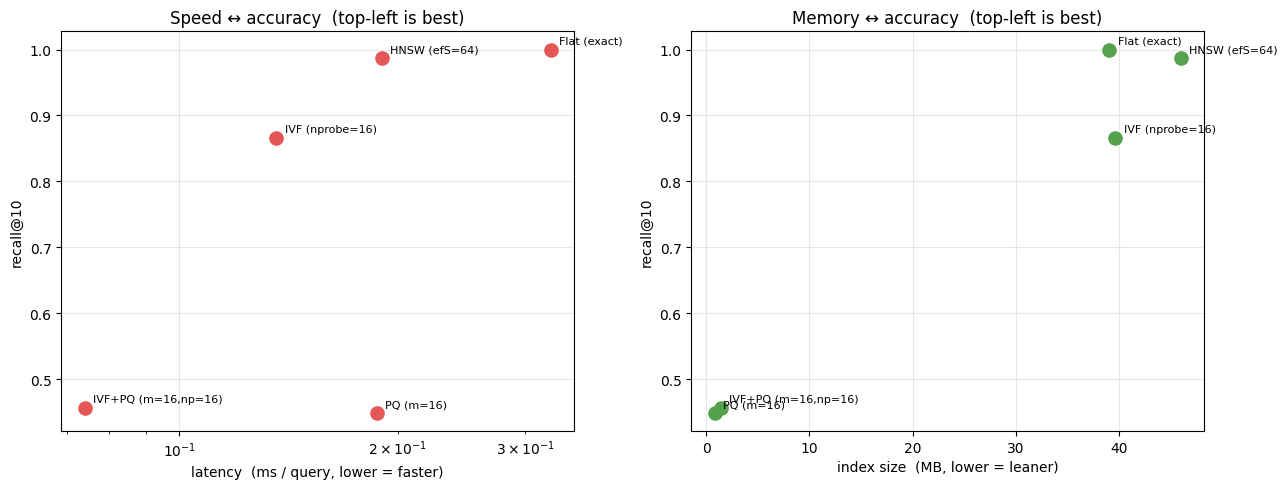

In [ ]:
# Two pictures tell the whole story: speed↔recall, and memory↔recall.
fig, ax = plt.subplots(1, 2, figsize=(13, 5))

ax[0].scatter(summary_df["ms/query"], summary_df["recall@k"], s=90, color="#E45756", zorder=3)
for _, r in summary_df.iterrows():
    ax[0].annotate(r["index"], (r["ms/query"], r["recall@k"]),
                   textcoords="offset points", xytext=(6, 4), fontsize=8)
ax[0].set_xlabel("latency  (ms / query, lower = faster)"); ax[0].set_ylabel(f"recall@{CFG.eval_k}")
ax[0].set_title("Speed ↔ accuracy  (top-left is best)"); ax[0].set_xscale("log"); ax[0].grid(alpha=0.3)

ax[1].scatter(summary_df["size_MB"], summary_df["recall@k"], s=90, color="#54A24B", zorder=3)
for _, r in summary_df.iterrows():
    ax[1].annotate(r["index"], (r["size_MB"], r["recall@k"]),
                   textcoords="offset points", xytext=(6, 4), fontsize=8)
ax[1].set_xlabel("index size  (MB, lower = leaner)"); ax[1].set_ylabel(f"recall@{CFG.eval_k}")
ax[1].set_title("Memory ↔ accuracy  (top-left is best)"); ax[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

### 9.1 · Which index should I use?

| Situation | Pick | Why |
|---|---|---|
| Small corpus (≲ 50k), or you need exact answers / a ground-truth baseline | **Flat** | Zero approximation, trivial to build; brute force is fast enough at this size |
| Need high recall **and** low latency, memory is not the bottleneck | **HNSW** | Best recall-per-ms; no training. Costs RAM (vectors + graph) and build time |
| Large corpus, latency matters, full vectors still fit in RAM | **IVF (Flat)** | Big speed-up via cell pruning, recall stays high, vectors kept intact |
| Corpus too big to store as float32 (tens of millions+) | **PQ** or **IVF+PQ** | PQ compresses 100×+; add IVF to also prune. The standard billion-scale combo |
| Frequent rebuilds / streaming inserts | **IVF / IVF+PQ** | Cheap to add to; HNSW rebuilds are pricier |

**Rules of thumb.** Start with Flat to get correct answers and a recall ceiling. Outgrow it on
*latency* → reach for HNSW (RAM-rich) or IVF (balanced). Outgrow it on *memory* → add PQ. The
combination **IVF+PQ** is the default for very large, production-scale stores. Always re-tune the
knob (`nprobe` / `efSearch` / `m`) against *your* data — recall is dataset-dependent, so measure,
don't guess.

### 9.2 · (Optional) Why this matters at scale

On our few-thousand-chunk corpus, Flat is already fast — the ANN win looks small. The gap explodes
as the corpus grows, because Flat is **O(N)** per query while IVF/HNSW are sub-linear. The cell
below builds a **synthetic** ~200k-vector set purely to illustrate that divergence. It is clearly
labelled synthetic and gated by a flag — set it to `False` to skip (it takes ~30–60 s on CPU).

In [ ]:
RUN_SCALING_DEMO = True  # set False to skip the ~200k-vector illustration

if RUN_SCALING_DEMO:
    rng = np.random.default_rng(CFG.seed)
    Nbig, Dbig, ncent = 200_000, 64, 200
    centers = rng.standard_normal((ncent, Dbig)).astype("float32")
    xb = centers[rng.integers(0, ncent, Nbig)] + 0.05 * rng.standard_normal((Nbig, Dbig)).astype("float32")
    xb /= (np.linalg.norm(xb, axis=1, keepdims=True) + 1e-9)
    xq = xb[rng.integers(0, Nbig, 1000)].copy()

    def _qps(ix, warmup_train=None):
        if warmup_train is not None: ix.train(xb)
        ix.add(xb)
        t0 = time.perf_counter(); ix.search(xq, 10); dt = time.perf_counter() - t0
        return round(len(xq) / dt)

    flat_b = faiss.IndexFlatIP(Dbig)
    ivf_q = faiss.IndexFlatIP(Dbig); ivf_b = faiss.IndexIVFFlat(ivf_q, Dbig, 1024, faiss.METRIC_INNER_PRODUCT)
    hnsw_b = faiss.IndexHNSWFlat(Dbig, 32, faiss.METRIC_INNER_PRODUCT); hnsw_b.hnsw.efSearch = 64

    qps_flat = _qps(flat_b)
    ivf_b.train(xb); ivf_b.add(xb); ivf_b.nprobe = 8
    t0 = time.perf_counter(); ivf_b.search(xq, 10); qps_ivf = round(len(xq) / (time.perf_counter() - t0))
    qps_hnsw = _qps(hnsw_b)

    scale_df = pd.DataFrame([
        {"index": "Flat",  "queries/sec @200k": qps_flat},
        {"index": "IVF",   "queries/sec @200k": qps_ivf},
        {"index": "HNSW",  "queries/sec @200k": qps_hnsw},
    ])
    print(f"SYNTHETIC {Nbig:,}×{Dbig} vectors — throughput (higher = better):")
    print(f"ANN indexes serve many× more queries/sec than brute force at this size.\n")
    display(scale_df)
else:
    print("Scaling demo skipped (RUN_SCALING_DEMO = False).")

SYNTHETIC 200,000×64 vectors — throughput (higher = better):
ANN indexes serve many× more queries/sec than brute force at this size.



,index,queries/sec @200k
0,Flat,252
1,IVF,19185
2,HNSW,8188


## 10 · Production touches

A working retriever is the start, not the finish. Four upgrades separate a demo from something you
would put behind an API:

1. **Persistence** — build the index once offline, reload it instantly at serve time.
2. **Metadata filtering** — restrict search to a paper, section, date range, tenant, …
3. **Hybrid search** — combine sparse keyword (BM25) with dense vectors so you catch both exact
   terms and paraphrases.
4. **Reranking** — re-score the shortlist with a cross-encoder for a precision boost.

### 10.1 · Persist the index + metadata, then reload

Embedding and index-building are the expensive, *offline* steps. In production you do them once and
ship two artefacts: the **FAISS index** (`faiss.write_index`) and a **sidecar** holding each
vector's text + metadata (here JSON; pickle/parquet/a real DB work too). At serve time you
`read_index` and the lookup table — milliseconds, no re-embedding.

In [ ]:
import json, os

PERSIST_DIR = os.path.join(SAMP, "rag_index"); os.makedirs(PERSIST_DIR, exist_ok=True)

# 1) the vector index
prod_index = faiss.IndexFlatIP(D); prod_index.add(CHUNK_VECS)
faiss.write_index(prod_index, os.path.join(PERSIST_DIR, "index.faiss"))

# 2) the sidecar: text + metadata, aligned 1:1 with vector ids (row order == add order)
sidecar = [{"text": c.page_content, **c.metadata} for c in CHUNKS]
with open(os.path.join(PERSIST_DIR, "chunks.json"), "w") as f:
    json.dump(sidecar, f)

size_mb = sum(os.path.getsize(os.path.join(PERSIST_DIR, f)) for f in os.listdir(PERSIST_DIR)) / 1e6
print(f"Wrote index + {len(sidecar)} chunk records to {PERSIST_DIR}  ({size_mb:.1f} MB on disk)")

# --- serve time: reload and sanity-check it still answers identically ---
reloaded = faiss.read_index(os.path.join(PERSIST_DIR, "index.faiss"))
with open(os.path.join(PERSIST_DIR, "chunks.json")) as f:
    reloaded_meta = json.load(f)

probe = EMB.embed_query(EVALSET[0]["question"])
_, I = reloaded.search(probe[None, :], 3)
print("\nReloaded index answers the first eval question with:")
for rank, idx in enumerate(I[0], 1):
    print(f"  {rank}. [{reloaded_meta[idx]['paper_id']}] {reloaded_meta[idx]['text'][:90]}...")

Wrote index + 25423 chunk records to /content/samples/rag_index  (50.7 MB on disk)

Reloaded index answers the first eval question with:
  1. [1701.02962] . Section "Baseline Models" ). We then feed each pattern $p$ of the word pair $(x,y)$ into...
  2. [1810.08699] The main model that we focused on was the recurrent model with a CRF top layer, and the ab...
  3. [1701.02962] . After introducing two baselines in Section "Baseline Models" , we describe our dataset, ...


### 10.2 · Metadata filtering

Often you must search *within a scope* — one paper, one customer's documents, a date window. Two
patterns: **pre-filter** (restrict the candidate id set before searching, e.g. FAISS `IDSelector`
on IVF) or the simpler, index-agnostic **post-filter** — over-fetch, then drop anything whose
metadata fails the predicate. We use post-filtering: robust, works on every index type, and cheap
as long as you fetch a healthy `k`.

In [ ]:
def filtered_search(query: str, where, k: int = 5, overfetch: int = 20):
    """Retrieve top-k chunks that satisfy a metadata predicate `where(meta) -> bool`."""
    qv = EMB.embed_query(query)
    scores, idx = prod_index.search(qv[None, :], overfetch)
    out = []
    for s, i in zip(scores[0], idx[0]):
        meta = sidecar[i]
        if where(meta):
            out.append((meta, float(s)))
        if len(out) == k:
            break
    return out

# Demo: same question, but restricted to a single paper.
target_pid = CHUNKS[0].metadata["paper_id"]
q = EVALSET[0]["question"]
hits = filtered_search(q, where=lambda m: m["paper_id"] == target_pid, k=3)
print(f"Q: {q}\nRestricted to paper_id={target_pid}:\n")
for meta, s in hits:
    print(f"  score={s:.3f}  chunk#{meta['chunk_id']}  {meta['text'][:90]}...")

Q: Is the LSTM baseline a sub-word model?
Restricted to paper_id=1912.01214:

  score=0.593  chunk#1912.01214::109  . Experiments on public datasets show that our approaches significantly outperforms severa...


### 10.3 · Hybrid search — dense + BM25 with Reciprocal Rank Fusion

Dense vectors capture *meaning* (paraphrases, synonyms) but can miss rare exact tokens — error
codes, IDs, surnames. Sparse **BM25** keyword scoring is the opposite. **Hybrid** retrieval runs
both and fuses the rankings with **Reciprocal Rank Fusion (RRF)**: a document's fused score is
`Σ 1/(k₀ + rank)` across lists, so anything ranked highly by *either* method floats up — no score
normalisation needed. Below we measure dense-only vs BM25-only vs hybrid on the eval set.

In [ ]:
from rank_bm25 import BM25Okapi
from collections import defaultdict
import re as _re

_tok = lambda t: _re.sub(r"[^\w]+", " ", t.lower()).split()      # token LIST (TF matters for BM25)
bm25 = BM25Okapi([_tok(t) for t in CHUNK_TEXTS])

# Dense scores for every eval query at once (normalised vectors → inner product == cosine).
DENSE = QVECS @ CHUNK_VECS.T                                       # (n_queries, n_chunks)

def rank_dense(i):  return list(np.argsort(-DENSE[i]))
def rank_bm25(i):   return list(np.argsort(-bm25.get_scores(_tok(EVALSET[i]["question"]))))

def rrf(rank_lists, k0=60, depth=100):
    agg = defaultdict(float)
    for rl in rank_lists:
        for rank, idx in enumerate(rl[:depth]):
            agg[int(idx)] += 1.0 / (k0 + rank + 1)
    return [i for i, _ in sorted(agg.items(), key=lambda x: -x[1])]

def eval_ranker(rank_fn):
    retrieved = [[CHUNKS[i] for i in rank_fn(qi)[:CFG.eval_k]] for qi in range(len(EVALSET))]
    return score_retrieval(retrieved, EVALSET, CFG.eval_k)

dense_only = eval_ranker(rank_dense)
bm25_only  = eval_ranker(rank_bm25)
hybrid     = eval_ranker(lambda i: rrf([rank_dense(i), rank_bm25(i)]))

hybrid_df = pd.DataFrame([
    {"method": "Dense (SBERT)", **{f"hit@{CFG.eval_k}": round(dense_only["hit@k"], 3), "MRR": round(dense_only["mrr"], 3)}},
    {"method": "BM25 (sparse)", **{f"hit@{CFG.eval_k}": round(bm25_only["hit@k"], 3),  "MRR": round(bm25_only["mrr"], 3)}},
    {"method": "Hybrid (RRF)",  **{f"hit@{CFG.eval_k}": round(hybrid["hit@k"], 3),     "MRR": round(hybrid["mrr"], 3)}},
])
print("Fusing dense + sparse usually matches or beats either alone:\n")
hybrid_df

Fusing dense + sparse usually matches or beats either alone:



,method,hit@10,MRR
0,Dense (SBERT),0.316,0.175
1,BM25 (sparse),0.315,0.197
2,Hybrid (RRF),0.353,0.224


### 10.4 · Reranking with a cross-encoder

Bi-encoders (our SBERT) embed query and document *separately* — fast, but they never directly
compare the two. A **cross-encoder** feeds `(query, chunk)` *together* through a transformer and
outputs one relevance score. It is far more accurate but too slow to run over the whole corpus —
so the production pattern is **retrieve-then-rerank**: cheap bi-encoder fetches a shortlist (say 20),
the cross-encoder re-scores just those. We measure the precision lift on a capped eval subset
(cross-encoders are slow on CPU).

In [ ]:
from sentence_transformers import CrossEncoder

reranker = CrossEncoder("cross-encoder/ms-marco-MiniLM-L-6-v2", device=DEVICE)
N_RERANK_EVAL = min(40, len(EVALSET))   # cap: cross-encoder is the slow part
SHORTLIST = 20

base_hits, base_rr, re_hits, re_rr = [], [], [], []
for qi in range(N_RERANK_EVAL):
    q = EVALSET[qi]
    cand = rank_dense(qi)[:SHORTLIST]                       # bi-encoder shortlist
    base = [CHUNKS[i] for i in cand]
    scores = reranker.predict([(q["question"], CHUNKS[i].page_content) for i in cand])
    reranked = [CHUNKS[i] for i, _ in sorted(zip(cand, scores), key=lambda x: -x[1])]

    for store_h, store_r, docs in [(base_hits, base_rr, base), (re_hits, re_rr, reranked)]:
        flags = [is_relevant(c, q) for c in docs[:CFG.eval_k]]
        store_h.append(1.0 if any(flags) else 0.0)
        store_r.append(next((1.0 / r for r, f in enumerate(flags, 1) if f), 0.0))

rerank_df = pd.DataFrame([
    {"stage": "Bi-encoder shortlist", f"hit@{CFG.eval_k}": round(np.mean(base_hits), 3), "MRR": round(np.mean(base_rr), 3)},
    {"stage": "+ Cross-encoder rerank", f"hit@{CFG.eval_k}": round(np.mean(re_hits), 3), "MRR": round(np.mean(re_rr), 3)},
])
print(f"Reranking the top-{SHORTLIST} on {N_RERANK_EVAL} questions — MRR lift shows better ordering:\n")
rerank_df

config.json:   0%|          | 0.00/794 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/90.9M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/105 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/1.33k [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/711k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/132 [00:00<?, ?B/s]

Reranking the top-20 on 40 questions — MRR lift shows better ordering:



,stage,hit@10,MRR
0,Bi-encoder shortlist,0.325,0.199
1,+ Cross-encoder rerank,0.375,0.243
